In [1]:
from  src.data_generator import DataGenerator
from src.models import LinearModel
import numpy as np
import matplotlib.pyplot as plt


In [2]:
''' Generating test_dataset also including true values. Kept the seed integer because test data doesnt change'''

error = 0.4 # This is standard deviation of normal distribution.
test_samplesize = 1000

test_data = DataGenerator(0.4, 1000)
X_test, t_test, t_test_true = test_data.Generate_Non_Linear_Data(42, False, True)


In [19]:
''' Now creating training Datasets. We will calcualte Bias, Variance and Var(e) for each of the dataset. Code is slighlty complex, check the .xopp in PRML_MLE_ANALYSIS file to understand the math better.

For every degree code creates a new predictions matrix, because for every individual degree each training dataset is trained to that degree and we save predictions.
'''

bias_squared = []
variance = []
raw_mse = []

training_data = DataGenerator(error, 25)

num_of_training_datasets = 100

for d in range(1,16): # d is degree

    predictions_matrix = np.zeros(shape=(num_of_training_datasets, test_samplesize))

    for l in range(num_of_training_datasets):

        X_train, t_train = training_data.Generate_Non_Linear_Data(seed=None,  standardize_data=True, return_true_outputs=False)
        

        model = LinearModel(d)
        model.fitNormalEquation(X_train, t_train)

        predictions = model.predict(X_test)

        predictions_matrix[l,:] = predictions[:,0]

    expected_predictions = (np.mean(predictions_matrix, axis=0)).reshape(-1,1)
    
    # Doing Bias Calculation
    bias_squared_per_point = (expected_predictions - t_test_true)**2
    total_bias_squared = np.mean(bias_squared_per_point) # This will return a single scaler value not a vector
    bias_squared.append(total_bias_squared)
    
    #Doing Variance Calculation
    variance_per_point = np.var(predictions_matrix, axis=0)
    total_variance = np.mean(variance_per_point) # This will also return a scalar value
    variance.append(total_variance)

    # Calculating Raw total MSE with noisy outputs
    t_test_noisy = t_test.flatten() # Using .flatten() to get to (N,) from column vector of (N,1) this will help code not to explode.

    raw_squared_errors = (predictions_matrix - t_test_noisy) ** 2 # Predictions matrix is (100, 1000) and subtatcitng a (1000,) t_test_noisy from it. It will take every column of predictions_matrix subtract t_test_noisy from it.

    noisy_mse = np.mean(raw_squared_errors) # This will take overall mean of full matrix. Giving us a single scalar ans
    raw_mse.append(noisy_mse)


bias_squared = np.array(bias_squared)
variance = np.array(variance)
theoretical_mse = bias_squared + variance + (error**2) # Theoritical mse or how raw mse is decomposed into this. Need to (error**2) because error is std_deviation 

raw_mse = np.array(raw_mse)

print(bias_squared)



[0.53647566 0.55340154 0.84348809 0.80982955 0.9725567  0.93607186
 1.07535531 1.01604349 0.87492621 0.91239639 0.96652289 0.92044001
 1.1739493  1.23543283 1.24912218]


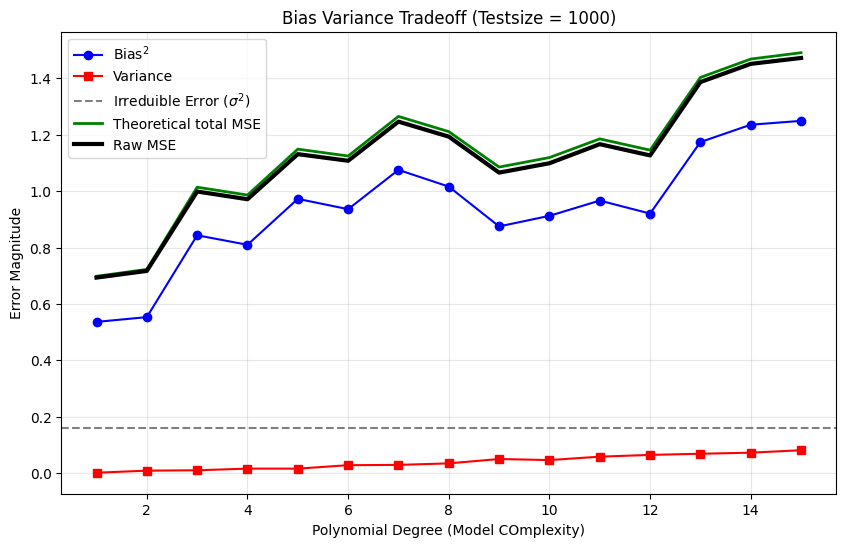

In [20]:
''' Plotting the Bias_Variance Tradeoff '''

degrees = np.arange(1,16)

# Setting up the canvas
plt.figure(figsize=(10,6))

# Plotting on Canvas
plt.plot(degrees, bias_squared, label='Bias$^2$', color='blue', marker='o')
plt.plot(degrees, variance, label='Variance', color='red', marker='s')


# Adding the irreducilbe error line which is (error**2), variance of error(e)
plt.axhline(y=(error**2), color='gray', linestyle='--', label='Irreduible Error ($\\sigma^2$)') # axhline is matplotlib function to plot a horizontal line on graph

# Plotting Theoritcial MSE and Raw MSE
# Adding line width so that it can be shown that theoretical mse and raw mse overlap.
plt.plot(degrees, theoretical_mse, label='Theoretical total MSE', color='green', linewidth=2)
plt.plot(degrees, raw_mse, label='Raw MSE', color='black', linewidth=3) 

# plt.ylim(0,0.6)

# Formatting the graph
plt.xlabel('Polynomial Degree (Model COmplexity)')
plt.ylabel('Error Magnitude')
plt.title("Bias Variance Tradeoff (Testsize = 1000)")
plt.legend()
plt.grid(True, alpha=0.3)

In [12]:
# ''' Doing analysis of how weights are calculated using normalequation and GRadient Descent '''

# training_data = DataGenerator(error, 25)
# X_train, t_train, temp = training_data.Generate_Non_Linear_Data(42)

# ''' For degree 1 y(xn,w) = w0 + w1xn'''

# # Using normal Equation 
# model = LinearModel(1)
# model.fitNormalEquation(X_train, t_train)
# print(f" Weights when using normal equation: {model.weights}")

# model.fitGradientDescent(X_train, t_train, 0.2, 1000)
# print(f"Weights using gradient Descent {model.weights}")
